# 03 - Back-EMF constant two ways

## Purpose

This notebook is the third in the series. It measures the back-EMF constant
$K_e$ of the motor, the voltage the winding generates per unit of speed, by
two routes that rest on different physics and different samples of the same
hardware, and it examines a third candidate channel that the data rejects.

This notebook has three jobs:

1. Measure $K_e$ by two independent routes and test their agreement
   (sections 5, 7 and 8). Route A needs the winding resistance $R$, which
   is anchored from the first two milliseconds of the full-duty steps
   (section 5.4).
2. Characterize the direct back-EMF channels, the terminal voltages read
   while the bridge leaves the winding floating, in the fast-decay drive
   grid (section 6) and in the coast segments (section 7).
3. Record the spread of every estimate across recordings (sections 5 to 7).

The dataset is three test series on one servo powered from a 2-cell lithium
battery. Speed is the derivative of the pot wiper voltage, in wiper volts
per second, as in notebook 00. The gear ratio between motor and wiper is
not known here, so $K_e$ is expressed in volts per wiper volt per second
and no claim is made about the motor shaft constant.


## 1. Test setup

The device under test and the signal chain are those of notebook 00,
section 1: an SG90-class hobby servo with replacement electronics, a
brushed DC motor behind an H-bridge at 20 kHz PWM, a pot wiper on the
output shaft read directly by the 12-bit ADC, a 33 mOhm shunt in the motor
return path with an amplifier of gain 15.0, and both motor terminals read
through 20 kOhm / 10 kOhm dividers. The bottom leg of each terminal divider
returns to a bias voltage $V_B$ of about 0.62 V, so
a terminal below ground still reads inside the ADC range. One frame of raw
ADC samples is streamed per 50 us control period.

Two facts about the bridge matter here.

- During the ON portion of a PWM period the bridge connects one terminal to
  the supply and the other to ground through the shunt.
- During the OFF portion the bridge has two modes. **Slow decay** closes
  both low-side switches and shorts the winding, so both terminals sit near
  ground and the winding current keeps circulating. **Fast decay** opens all
  four switches. The winding current then returns to the supply through the
  body diodes, during which the terminal that carries the current out of the
  winding sits one diode drop above the supply, the other sits one diode
  drop below ground, and the shunt reads negative. Once the current reaches
  zero the winding floats and the terminals carry the open-circuit back-EMF.

A **coast** segment is fast decay held at zero duty, so the winding floats
for the whole segment. A **brake** segment is slow decay at zero duty, so
the winding stays shorted.

Each sample row carries a shunt reading and both terminal readings taken at
one fixed point of the PWM period, the **crest scan**, plus a second shunt
reading from the opposite point of the period, the **trough scan**. Under
slow decay the crest scan falls inside the ON portion once the drive width
reaches 160 of the 1200 timer ticks (13.3% duty), and the firmware marks
those samples valid. Under fast decay the crest scan falls in the OFF
portion (notebook 01, section 5.3).

### 1.1 Model and routes

The winding obeys

$$v = R\,i + L\,\frac{di}{dt} + K_e\,\omega$$

with $v$ the terminal voltage, $i$ the winding current, $R$ the winding
resistance (brushes included), $L$ the winding inductance, $\omega$ the
speed and $K_e$ the back-EMF constant. Averaged over one PWM period at
steady speed the inductive term averages to zero. Under slow decay the OFF
portion applies zero volts, so the mean terminal voltage is the duty times
the ON-portion terminal difference:

$$\bar v = D\,(v_{\mathrm{drv}} - v_{\mathrm{idle}}) = R\,\bar i + K_e\,\omega$$

With the winding open, $i = 0$ and the terminal difference equals
$K_e\,\omega$ directly.

- **Route A** uses slow-decay drive steps at steady speed. The mean
  voltage, mean current and speed of every valid step are fitted to the
  averaged equation, with $R$ anchored from the first milliseconds of the
  full-duty steps, before the mechanism has gathered speed.
- **Route C** uses the coast segments. The floating terminal difference is
  regressed on the instantaneous speed as the mechanism spins down.
- The **fast-decay crest sample**, one terminal reading per PWM period
  taken in the OFF portion, is the candidate for a direct back-EMF channel
  inside a drive step. Section 6 tests it against speed and current.

Route C and the candidate share the terminal channel and the
floating-winding physics. Route A shares nothing with them beyond the pot
wiper and the terminal dividers.


## 2. Constants and unit conversions

All conversions from ADC counts to physical units use the constants below,
identical to notebook 00 except for the terminal bias.

| Quantity | Value |
|---|---|
| ADC resolution | 12 bit (0..4095 counts) |
| ADC reference | VDD, nominal 3.300 V |
| Motor terminal divider | 20 kOhm top / 10 kOhm bottom |
| Terminal divider return (bias) | 430 Ohm / 100 Ohm from VDD, nominal 0.623 V |
| Current shunt | 33 mOhm |
| Current amplifier gain | 15.0 |
| Control period | 50 us (20 kHz) |
| PWM period | 1200 timer ticks |
| Duty encoding | signed, 32767 = 100% |
| Sampling validity threshold | 160 timer ticks = 13.3% duty |

With the divider returned to $V_B$, the ADC tap of a terminal at $V_t$
reads

$$v_{\mathrm{tap}} = \frac{V_t}{3} + \frac{2}{3}\,V_B
\qquad\Longleftrightarrow\qquad
V_t = 3\,v_{\mathrm{tap}} - 2\,V_B$$

Every absolute terminal voltage below (the rail, the idle terminal, the
coast terminals) uses the second form. The difference of two terminals is
bias-free, $V_a - V_b = 3\,(v_{\mathrm{tap},a} - v_{\mathrm{tap},b})$, so
the applied voltage of route A, built from the difference of the driven
and idle terminals, and the coast back-EMF, built from the difference of
the two floating terminals, need no bias at all.

$V_B$ is measured per recording. The nominal resistor ratio gives 0.623 V. With the bridge off and the mechanism at rest both taps sit
at $V_B$, so the median of the one-second baseline of one terminal gives
it, and the other terminal cross-checks it. Section 4 tabulates it.

Three caveats:

- The ADC reference is the chip's VDD supply. The 3.300 V figure is the
  design value, and the actual VDD of this unit was not measured. Every
  voltage below scales linearly with the true VDD. $K_e$ is a ratio of a
  terminal voltage to a wiper voltage per second, and both scale with VDD,
  so $K_e$ itself does not depend on it. $R$ does.
- The divider, shunt, and gain are design values. Component tolerances
  were not measured, and absolute voltages and currents carry them.
- $V_B$ enters only the absolute terminal voltages. A 1-count error in it
  moves an absolute terminal reading by 2 counts, about 5 mV.

The derived conversion factors:


In [1]:
from pathlib import Path

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# --- documented constants (see the table above) ---
VDD_V = 3.300               # ADC reference, nominal, not measured
ADC_COUNTS = 4096           # 12-bit converter
DIV_TOP_OHM = 20_000        # motor terminal divider, top leg
DIV_BOT_OHM = 10_000        # motor terminal divider, bottom leg
BIAS_TOP_OHM = 430          # divider return bias, from VDD
BIAS_BOT_OHM = 100          # divider return bias, to ground
SHUNT_OHM = 0.033           # current shunt
AMP_GAIN = 15.0             # current amplifier gain
TICK_HZ = 20_000            # control / sample rate
PWM_PERIOD_TICKS = 1200     # timer ticks per PWM period
Q15 = 32767                 # duty full scale as encoded on the wire

# --- derived conversion factors ---
V_ADC_PER_COUNT = VDD_V / ADC_COUNTS                       # volts at the ADC pin
DIV_RATIO = (DIV_TOP_OHM + DIV_BOT_OHM) / DIV_BOT_OHM      # 3, terminal volts per tap volt
A_PER_COUNT = V_ADC_PER_COUNT / (AMP_GAIN * SHUNT_OHM)     # amps through the shunt
VB_NOMINAL_V = VDD_V * BIAS_BOT_OHM / (BIAS_TOP_OHM + BIAS_BOT_OHM)

def terminal_V(tap_counts, vb_counts):
    return (DIV_RATIO * tap_counts - (DIV_RATIO - 1) * vb_counts) * V_ADC_PER_COUNT

pd.DataFrame([
    {"channel": "pot wiper", "factor": V_ADC_PER_COUNT * 1e3, "unit": "mV per count"},
    {"channel": "motor terminal, absolute", "factor": DIV_RATIO * V_ADC_PER_COUNT * 1e3, "unit": "mV per tap count, minus 2 x VB"},
    {"channel": "motor terminal, difference", "factor": DIV_RATIO * V_ADC_PER_COUNT * 1e3, "unit": "mV per count of tap difference"},
    {"channel": "motor current", "factor": A_PER_COUNT * 1e3, "unit": "mA per count"},
    {"channel": "terminal bias VB, nominal", "factor": VB_NOMINAL_V, "unit": "V"},
]).set_index("channel").round(4)


,factor,unit
channel,,
pot wiper,0.8057,mV per count
"motor terminal, absolute",2.4170,"mV per tap count, minus 2 x VB"
"motor terminal, difference",2.4170,mV per count of tap difference
motor current,1.6276,mA per count
"terminal bias VB, nominal",0.6226,V


## 3. Capture method

Three test series, all from the same servo and the same battery in one
session without recharging, streamed at the full 20 kHz sample rate with a
CRC on every frame. Corrupted frames are dropped and counted, so corruption
turns into missing samples.

- **Slow-decay grid.** The 41-segment recording of notebook 00: a
  one-second baseline with the motor undriven, then 80 ms constant-duty
  drive steps from 5% to 100% in 5% increments, forward then reverse, each
  preceded by a repositioning move toward the far end of travel and
  followed by 500 ms of rest. Fifteen recordings, ten in one series and
  five alongside the other two series.
- **Fast-decay grid.** The same 41-segment grid with the bridge in fast
  decay during the drive steps. Five recordings.
- **Spin-down.** A one-second baseline, then for each direction the
  sequence drive 20% for 80 ms, coast 400 ms, drive 20%, brake 400 ms,
  drive 30%, coast, drive 30%, brake, drive 40%, coast, drive 40%, brake.
  Twenty-five segments per recording, five recordings. The zero-duty
  segments alternate coast and brake and are identified by their position
  in the recorded schedule.

**Data acceptance.** Any recording with a dropped frame was discarded and
re-run. Section 4 re-verifies this from the tick column.

Each row of a recording is one 50 us sample and carries the segment
number, commanded duty, direction, tick counter, the validity flag, and
the raw channels (position, crest-scan shunt, trough-scan shunt, both
crest-scan terminals).


In [2]:
TELEMETRY = Path("telemetry/sg90")

def load(csv, meta):
    df = pd.read_csv(csv)
    df["duty_pct"] = df["cmd_duty_q15"] * 100.0 / Q15
    return df, json.loads(Path(meta).read_text())

def capture_dirs(base):
    return sorted(base.glob("capture-*"), key=lambda p: int(p.name.split("-")[1]))

slow, fast, spin = {}, {}, {}
for d in capture_dirs(TELEMETRY / "2s"):
    slow[f"2s/{d.name}"] = load(d / "sweep.csv.gz", d / "meta.json")
for d in capture_dirs(TELEMETRY / "bridge"):
    slow[f"bridge/{d.name}"] = load(d / "slow.csv.gz", d / "slow.meta.json")
    fast[f"bridge/{d.name}"] = load(d / "fast.csv.gz", d / "fast.meta.json")
    spin[f"bridge/{d.name}"] = load(d / "spindown.csv.gz", d / "spindown.meta.json")

pd.DataFrame({"recordings": [len(slow), len(fast), len(spin)]},
             index=["slow-decay grid", "fast-decay grid", "spin-down"])


,recordings
slow-decay grid,15
fast-decay grid,5
spin-down,5


## 4. Data integrity and terminal bias

One frame carries 16 consecutive samples, so a dropped frame appears as a
16-tick jump inside a segment. The table recomputes the missing-sample
count of every recording from the tick column. It also reports the lowest
duty step at which the validity flag is set, which route A relies on, and
the terminal bias $V_B$ of the recording as the baseline median of each
terminal tap.


In [3]:
def bias_counts(df):
    return df[df["seg"] == 0]["vmotor_a"].median()

def integrity(recs, series):
    rows = []
    for name, (df, _) in recs.items():
        missing = 0
        for _, seg in df.groupby("seg"):
            ticks = seg["tick"].to_numpy()
            missing += int(ticks[-1] - ticks[0] + 1 - len(ticks))
        steps = df[df["seg"] > 0].groupby("seg").agg(
            d=("duty_pct", "first"), valid=("window_valid", "mean"))
        steps = steps[steps["d"] != 0]
        base = df[df["seg"] == 0]
        rows.append({
            "series": series,
            "recording": name,
            "samples": len(df),
            "segments": df["seg"].nunique(),
            "missing_samples": missing,
            "flag_set_from_pct": steps[steps["valid"] > 0.5]["d"].abs().min().round(),
            "VB_a_counts": base["vmotor_a"].median(),
            "VB_b_counts": base["vmotor_b"].median(),
            "VB_V": bias_counts(df) * V_ADC_PER_COUNT,
        })
    return pd.DataFrame(rows)

pd.concat([integrity(slow, "slow-decay grid"),
           integrity(fast, "fast-decay grid"),
           integrity(spin, "spin-down")], ignore_index=True).round(4)


,series,recording,samples,segments,missing_samples,flag_set_from_pct,VB_a_counts,VB_b_counts,VB_V
0,slow-decay grid,2s/capture-1,84000,41,0,15.0,777.0,778.0,0.6260
1,slow-decay grid,2s/capture-2,84000,41,0,15.0,777.0,779.0,0.6260
2,slow-decay grid,2s/capture-3,84000,41,0,15.0,777.0,779.0,0.6260
3,slow-decay grid,2s/capture-4,84000,41,0,15.0,776.0,778.0,0.6252
4,slow-decay grid,2s/capture-5,84000,41,0,15.0,777.0,778.0,0.6260
5,slow-decay grid,2s/capture-6,84000,41,0,15.0,777.0,779.0,0.6260
6,slow-decay grid,2s/capture-7,84000,41,0,15.0,777.0,779.0,0.6260
7,slow-decay grid,2s/capture-8,84000,41,0,15.0,777.0,779.0,0.6260
8,slow-decay grid,2s/capture-9,84000,41,0,15.0,777.0,779.0,0.6260
9,slow-decay grid,2s/capture-10,84000,41,0,15.0,777.0,779.0,0.6260


Every recording has zero missing samples. In every grid recording the
flag is set from the 15% step up and clear at 10%, consistent with the
160-tick threshold. The spin-down drive steps are all at or above 20%.

The bias reads 776 to 777 counts on one terminal and 778 to 779 on the
other in all 25 recordings, 0.625 to 0.626 V against the nominal 0.623 V.
The first 100 ms of every baseline is the tail of a free coast from the
positioning move, with the taps split around $V_B$ and the pot still
moving, and the full-second median absorbs it.

## 5. Route A: slow-decay drive steps

### 5.1 Per-step quantities

For every drive step with the validity flag set:

- **Applied voltage** $\bar v = D\,(v_{\mathrm{drv}} - v_{\mathrm{idle}})$.
  The driven terminal is the 90th percentile of its valid crest-scan
  samples, the supply estimate of notebook 00, section 6.2. The idle
  terminal is the median of its valid samples (the low-side switch and
  shunt drop). Both are converted with $3\,v_{\mathrm{tap}} - 2\,V_B$, and
  the bias cancels in their difference, so the applied voltage has the same
  form as before the bias existed.
- **Current** $\bar i$ is the mean valid crest-scan shunt reading minus
  the baseline offset of the same recording (notebook 00, section 5.2),
  signed by direction. The crest scan sits at the centre of the ON portion,
  and the current ripple within a period is close to triangular, so the
  centre sample is taken as the period mean.
- **Speed** $\omega$ is the slope of a least-squares line through the last
  60% of the step's wiper trace, the method of notebook 00, section 6.3.

Notebook 00 restricted the supply estimate to 25% duty and above. In these
recordings the crest-scan terminals read the supply at every flagged step,
so the restriction is dropped and the 15% and 20% steps are included.


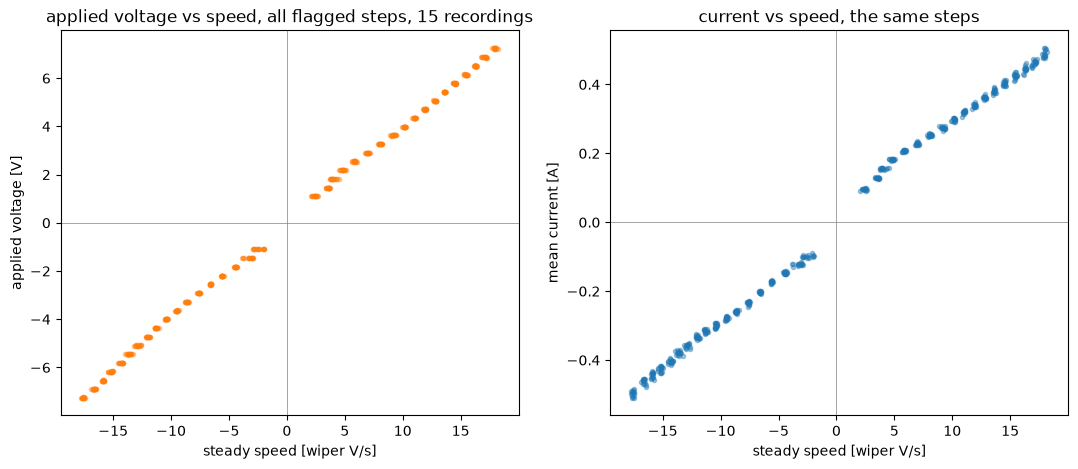

,speed_Vps,valid_frac,rail_V,idle_V,current_A,applied_V
duty_pct,,,,,,
14.999847,2.561,0.999,7.372,0.070,0.099,1.095
19.998779,3.363,0.999,7.362,0.073,0.131,1.458
24.997711,3.964,0.999,7.360,0.077,0.155,1.820
29.999695,5.062,0.999,7.355,0.082,0.185,2.182
34.998627,5.981,0.999,7.352,0.085,0.209,2.544
39.997559,6.984,0.999,7.352,0.092,0.235,2.904
44.999542,8.126,0.999,7.350,0.092,0.252,3.266
49.998474,9.235,0.999,7.348,0.097,0.278,3.625
54.997406,10.164,0.999,7.345,0.102,0.302,3.984


In [4]:
def current_bias(df):
    return df[df["seg"] == 0]["current_raw"].mean()

def step_speed(seg):
    n = len(seg)
    tail = seg.iloc[int(n * 0.4):]
    t = (tail["tick"] - tail["tick"].iloc[0]) / TICK_HZ
    return np.polyfit(t, tail["pos"] * V_ADC_PER_COUNT, 1)[0]

def drive_steps(df):
    vb = bias_counts(df)
    bias = current_bias(df)
    out = []
    for seg_id, seg in df.groupby("seg"):
        d = seg["duty_pct"].iloc[0]
        if seg_id == 0 or d == 0:
            continue
        drv, idle = ("vmotor_a", "vmotor_b") if d > 0 else ("vmotor_b", "vmotor_a")
        v = seg[seg["window_valid"] == 1]
        row = {"duty_pct": d, "speed_Vps": step_speed(seg),
               "valid_frac": seg["window_valid"].mean()}
        if len(v) >= 100:
            row.update({
                "rail_V": terminal_V(v[drv].quantile(0.9), vb),
                "idle_V": terminal_V(v[idle].median(), vb),
                "current_A": np.sign(d) * (v["current_raw"].mean() - bias) * A_PER_COUNT,
            })
        out.append(row)
    s = pd.DataFrame(out)
    s["applied_V"] = s["duty_pct"] / 100.0 * (s["rail_V"] - s["idle_V"])
    return s

steps_a = {name: drive_steps(df).dropna(subset=["current_A"])
           for name, (df, _) in slow.items()}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, s in steps_a.items():
    axes[0].plot(s["speed_Vps"], s["applied_V"], "o", ms=3, alpha=0.4, color="tab:orange")
    axes[1].plot(s["speed_Vps"], s["current_A"], "o", ms=3, alpha=0.4, color="tab:blue")
axes[0].set_xlabel("steady speed [wiper V/s]")
axes[0].set_ylabel("applied voltage [V]")
axes[0].set_title("applied voltage vs speed, all flagged steps, 15 recordings")
axes[1].set_xlabel("steady speed [wiper V/s]")
axes[1].set_ylabel("mean current [A]")
axes[1].set_title("current vs speed, the same steps")
for ax in axes:
    ax.axhline(0, color="grey", lw=0.5)
    ax.axvline(0, color="grey", lw=0.5)
plt.show()

steps_a["bridge/capture-1"].set_index("duty_pct").round(3)


The rail reads 7.33 to 7.40 V across all flagged steps of all 15
recordings and the idle terminal 0.04 to 0.14 V, rising with current. The
right panel is the problem of route A in one picture. Current and speed
rise together across the grid, so the two regressors of the joint fit are
nearly proportional and the fit can trade $R$ against $K_e$ with little
change in residual. Section 5.3 quantifies this and section 5.4 breaks the
tie with an independent $R$.

### 5.2 Joint fit

Per recording, $\bar v = R\,\bar i + K_e\,\omega$ is fitted by least
squares over all flagged steps of both directions with no intercept. The
signs are consistent by construction, since reverse steps carry negative
voltage, negative current and negative speed.


In [5]:
def fit_route_a(s):
    A = np.column_stack([s["current_A"], s["speed_Vps"]])
    x, _, _, sv = np.linalg.lstsq(A, s["applied_V"], rcond=None)
    resid = s["applied_V"] - A @ x
    return {"R_ohm": x[0], "Ke_V_per_Vps": x[1],
            "rms_resid_V": np.sqrt(np.mean(resid ** 2)),
            "corr_i_w": np.corrcoef(s["current_A"], s["speed_Vps"])[0, 1],
            "condition": sv[0] / sv[1], "steps": len(s)}

fits_a = pd.DataFrame([{"recording": n, **fit_route_a(s)} for n, s in steps_a.items()])
fits_a.set_index("recording").round(4)


,R_ohm,Ke_V_per_Vps,rms_resid_V,corr_i_w,condition,steps
recording,,,,,,
2s/capture-1,3.6748,0.2994,0.1283,0.9978,527.4979,36
2s/capture-2,2.9308,0.3188,0.1296,0.9978,526.4841,36
2s/capture-3,3.2388,0.3084,0.1147,0.9980,561.2597,36
2s/capture-4,2.3039,0.3359,0.1167,0.9984,609.3056,36
2s/capture-5,3.4594,0.3049,0.1338,0.9977,513.9121,36
2s/capture-6,0.9486,0.3760,0.1175,0.9982,579.6389,36
2s/capture-7,1.8302,0.3511,0.1198,0.9980,560.2303,36
2s/capture-8,2.1955,0.3399,0.1132,0.9982,571.9274,36
2s/capture-9,3.0747,0.3140,0.1341,0.9978,533.9348,36


In [6]:
summary_a = fits_a[["R_ohm", "Ke_V_per_Vps"]].agg(["mean", "std", "min", "max"]).T
summary_a["spread_pct"] = summary_a["std"] / summary_a["mean"].abs() * 100
summary_a.round(4)


,mean,std,min,max,spread_pct
R_ohm,2.5060,0.9249,0.3700,3.6748,36.9064
Ke_V_per_Vps,0.3304,0.0261,0.2994,0.3894,7.8857


### 5.3 Collinearity

The correlation between current and speed across the steps of a recording
is above 0.997 and the condition number of the design matrix is above 500.
The joint fit therefore pins one combination of $R$ and $K_e$ and leaves
the split between them weak. To make this concrete, for one recording
$K_e$ is stepped through a grid, $R$ is refitted at each value, and the
residual is tabulated. A shallow valley means the data cannot choose.


In [7]:
def ke_at_fixed_r(s, r):
    return np.sum(s["speed_Vps"] * (s["applied_V"] - r * s["current_A"])) / np.sum(s["speed_Vps"] ** 2)

s = steps_a["bridge/capture-1"]
rows = []
for ke in np.arange(0.15, 0.50, 0.05):
    r = np.sum(s["current_A"] * (s["applied_V"] - ke * s["speed_Vps"])) / np.sum(s["current_A"] ** 2)
    resid = s["applied_V"] - r * s["current_A"] - ke * s["speed_Vps"]
    rows.append({"Ke_fixed": round(ke, 2), "R_refit_ohm": r,
                 "rms_resid_V": np.sqrt(np.mean(resid ** 2))})
pd.DataFrame(rows).set_index("Ke_fixed").round(4)


,R_refit_ohm,rms_resid_V
Ke_fixed,,
0.15,8.7061,0.1766
0.20,6.9736,0.1519
0.25,5.2411,0.1321
0.30,3.5086,0.1197
0.35,1.7761,0.1171
0.40,0.0436,0.1248
0.45,-1.6889,0.1412


Findings:

- The joint fit gives $K_e$ = 0.33 V per wiper V/s with an 8% spread
  across 15 recordings, and $R$ = 2.5 Ohm with a 37% spread. $R$ is poorly
  determined, and the recording spread of $K_e$ is the mirror image of it.
- The residual valley is shallow. Moving $K_e$ from 0.25 to 0.35 changes
  the rms residual from 0.132 V to 0.117 V while $R$ swings from 5.2 Ohm to
  1.8 Ohm. Route A on its own supports any $K_e$ from about 0.25 to 0.40
  with the matching $R$, and pins the combination
  $R + 35\,K_e \approx 13.9$ Ohm far better than either term.
- The residuals are structured, of opposite sign in the two directions at
  the lowest and highest duties, so the averaged equation with two
  constants does not describe the steps to better than about 0.1 V.
  Notebook 00 showed the slowest steps are still accelerating at the end of
  the 80 ms window, which biases their speeds low and contributes to this.

### 5.4 An independent anchor for R

The full-duty steps offer $R$ on its own. When the bridge switches on, the
current rises to its stall value within a few hundred microseconds, the
inductive term dies with it, and the mechanism has not yet gathered speed.
Over the window from 0.6 ms to 2 ms after the bridge switches on, the ratio
of the mean terminal difference to the mean crest-scan current is $R$ plus
whatever back-EMF the mechanism carries into the window, divided by the
current.

That residual back-EMF is the caveat. The positioning move that precedes
each step runs toward the far end of travel at the 15% seek duty and ends
at the step edge, so the mechanism enters the step moving backward. Two
readings show it. The first sample of the segment, before the bridge
switches on, carries no current and reads the terminal difference of the
free winding, a backward EMF. The pot's slope over the first 2 ms reads the
backward speed. Both are tabulated per step. The figure averages the first
10 ms of all 30 full-duty steps, with the anchor window shaded.


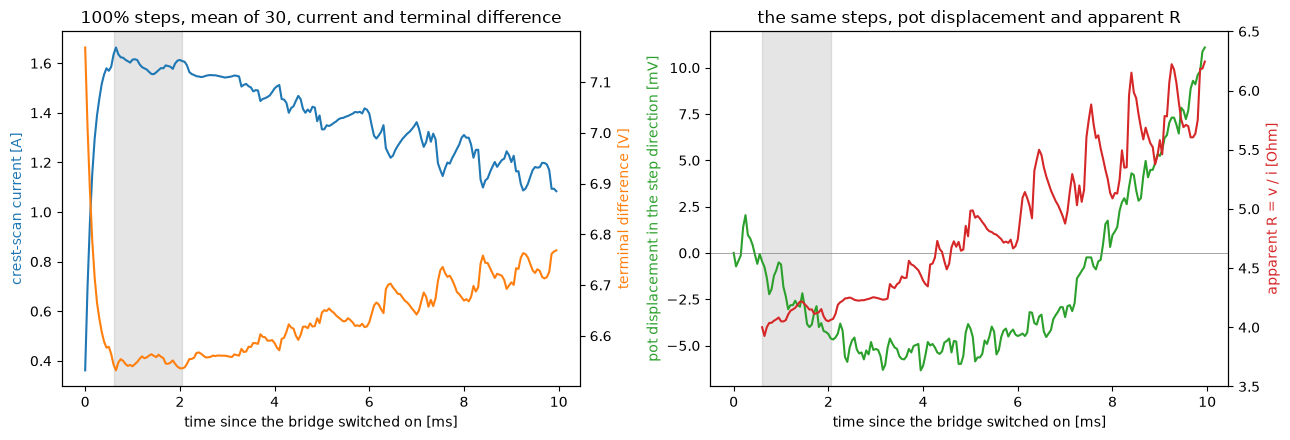

bridge_on_sample  e_edge_V  i_edge_A  \
recording        direction                                         
2s/capture-1      1                        2    -0.786     0.005   
                 -1                        2    -0.788     0.004   
2s/capture-2      1                        3    -0.769     0.002   
                 -1                        3    -0.781     0.004   
2s/capture-3      1                        2    -0.723     0.002   
                 -1                        2    -0.807     0.004   
2s/capture-4      1                        3    -0.781     0.002   
                 -1                        2    -0.677     0.006   
2s/capture-5      1                        2    -0.778     0.006   
                 -1                        2    -0.773     0.001   
2s/capture-6      1                        2    -0.752     0.005   
                 -1                        2    -0.660     0.007   
2s/capture-7      1                        3    -0.805    -0.001   
                 -1                        2    -0.807     0.000   
2s/capture-8      1                        2    -0.769     0.002   
                 -1                        2    -0.674     0.003   
2s/capture-9      1                        2    -0.682     0.004   
                 -1                        3    -0.660     0.009   
2s/capture-10     1                        2    -0.587     0.007   
                 -1                        3    -0.781    -0.001   
bridge/capture-1  1                        2    -0.742     0.002   
                 -1                        3    -0.568     0.005   
bridge/capture-2  1                        3    -0.776     0.011   
                 -1                        2    -0.624     0.008   
bridge/capture-3  1                        3    -0.735     0.005   
                 -1                        2    -0.711     0.007   
bridge/capture-4  1                        3    -0.754     0.005   
                 -1                        3    -0.636     0.003   
bridge/capture-5  1                        2    -0.759     0.006   
                 -1                        2    -0.781     0.004   

                            pot_speed_2ms_Vps  v_window_V  i_window_A  \
recording        direction                                              
2s/capture-1      1                    -2.094       6.568       1.590   
                 -1                    -4.960       6.570       1.584   
2s/capture-2      1                    -5.513       6.546       1.636   
                 -1                    -3.759       6.549       1.619   
2s/capture-3      1                    -3.133       6.549       1.624   
                 -1                    -1.957       6.588       1.533   
2s/capture-4      1                    -4.214       6.558       1.597   
                 -1                    -2.493       6.555       1.609   
2s/capture-5      1                    -1.437       6.548       1.619   
                 -1                    -1.594       6.543       1.618   
2s/capture-6      1                    -0.528       6.558       1.587   
                 -1                    -1.715       6.577       1.541   
2s/capture-7      1                    -2.964       6.547       1.605   
                 -1                    -4.141       6.584       1.529   
2s/capture-8      1                    -2.237       6.556       1.583   
                 -1                    -3.150       6.547       1.601   
2s/capture-9      1                    -0.626       6.556       1.576   
                 -1                    -1.943       6.520       1.657   
2s/capture-10     1                    -4.492       6.559       1.569   
                 -1                    -3.116       6.573       1.538   
bridge/capture-1  1                    -0.915       6.526       1.643   
                 -1                    -2.891       6.565       1.559   
bridge/capture-2  1                    -1.670       6.533       1.617   
                 -1       

In [8]:
ANCHOR_WINDOW = (12, 41)                 # samples after the bridge switches on, 0.6 ms to 2 ms
LATER_WINDOWS = {"R_0.6_1ms": (12, 21), "R_1_2ms": (21, 41), "R_2_3ms": (41, 61), "R_3_4ms": (61, 81)}
TRACE_SAMPLES = 200                      # 10 ms of the step start kept for the figure
BRIDGE_ON_A = 0.1                        # current that marks the first sample with the bridge on

def full_duty_steps(df):
    vb = bias_counts(df)
    bias = current_bias(df)
    for seg_id, seg in df.groupby("seg"):
        d = seg["duty_pct"].iloc[0]
        if seg_id == 0 or abs(d) < 99.9:
            continue
        sgn = int(np.sign(d))
        v = sgn * DIV_RATIO * (seg["vmotor_a"] - seg["vmotor_b"]).to_numpy() * V_ADC_PER_COUNT
        i = (seg["current_raw"].to_numpy() - bias) * A_PER_COUNT
        pos = sgn * seg["pos"].to_numpy() * V_ADC_PER_COUNT
        on = int(np.flatnonzero(i > BRIDGE_ON_A)[0])
        yield sgn, on, v, i, pos

def window_ratio(v, i, on, lo, hi):
    return v[on + lo:on + hi].mean() / i[on + lo:on + hi].mean()

rows, traces = [], []
lo, hi = ANCHOR_WINDOW
t2 = np.arange(41) / TICK_HZ
for name, (df, _) in slow.items():
    for sgn, on, v, i, pos in full_duty_steps(df):
        row = {"recording": name, "direction": sgn, "bridge_on_sample": on,
               "e_edge_V": v[0], "i_edge_A": i[0],
               "pot_speed_2ms_Vps": np.polyfit(t2, pos[on:on + 41], 1)[0],
               "v_window_V": v[on + lo:on + hi].mean(),
               "i_window_A": i[on + lo:on + hi].mean(),
               "R_window_ohm": window_ratio(v, i, on, lo, hi)}
        row.update({k: window_ratio(v, i, on, a, b) for k, (a, b) in LATER_WINDOWS.items()})
        rows.append(row)
        traces.append(np.column_stack([i[on:on + TRACE_SAMPLES], v[on:on + TRACE_SAMPLES],
                                       (pos[on:on + TRACE_SAMPLES] - pos[on]) * 1e3]))
anchor = pd.DataFrame(rows)
mean_trace = np.mean(traces, axis=0)
tm = np.arange(TRACE_SAMPLES) / TICK_HZ * 1e3

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.plot(tm, mean_trace[:, 0], color="tab:blue")
ax.set_ylabel("crest-scan current [A]", color="tab:blue")
ax2 = ax.twinx()
ax2.plot(tm, mean_trace[:, 1], color="tab:orange")
ax2.set_ylabel("terminal difference [V]", color="tab:orange")
ax.axvspan(lo / TICK_HZ * 1e3, hi / TICK_HZ * 1e3, color="grey", alpha=0.2)
ax.set_xlabel("time since the bridge switched on [ms]")
ax.set_title("100% steps, mean of 30, current and terminal difference")
ax = axes[1]
ax.plot(tm, mean_trace[:, 2], color="tab:green")
ax.set_ylabel("pot displacement in the step direction [mV]", color="tab:green")
ax.axhline(0, color="grey", lw=0.5)
ax2 = ax.twinx()
ax2.plot(tm[lo:], mean_trace[lo:, 1] / mean_trace[lo:, 0], color="tab:red")
ax2.set_ylabel("apparent R = v / i [Ohm]", color="tab:red")
ax2.set_ylim(3.5, 6.5)
ax.axvspan(lo / TICK_HZ * 1e3, hi / TICK_HZ * 1e3, color="grey", alpha=0.2)
ax.set_xlabel("time since the bridge switched on [ms]")
ax.set_title("the same steps, pot displacement and apparent R")
fig.tight_layout()
plt.show()

anchor.set_index(["recording", "direction"]).round(3)


In [9]:
cols = ["R_window_ohm", *LATER_WINDOWS, "e_edge_V", "i_edge_A", "pot_speed_2ms_Vps", "i_window_A"]
summary_r = anchor[cols].agg(["mean", "std", "min", "max"]).T
summary_r["spread_pct"] = summary_r["std"] / summary_r["mean"].abs() * 100
summary_r.round(4)


,mean,std,min,max,spread_pct
R_window_ohm,4.1034,0.1161,3.8778,4.3048,2.8290
R_0.6_1ms,4.0370,0.1964,3.5723,4.2748,4.8645
R_1_2ms,4.1399,0.1668,3.7785,4.3303,4.0288
R_2_3ms,4.2347,0.3118,3.2177,4.4315,7.3628
R_3_4ms,4.3874,0.1677,3.9669,4.5626,3.8220
e_edge_V,-0.7307,0.0672,-0.8073,-0.5680,9.1969
i_edge_A,0.0041,0.0028,-0.0015,0.0108,67.8773
pot_speed_2ms_Vps,-2.6413,1.3067,-5.5133,-0.5278,49.4715
i_window_A,1.5973,0.0407,1.5295,1.6768,2.5475


Findings:

- The window ratio repeats to 2.8% across the 30 steps, 4.10 Ohm with a
  spread of 0.12 Ohm.
- Every step enters moving backward. The edge sample reads a backward EMF
  of 0.57 to 0.81 V with at most 0.011 A of current, and the pot's 2 ms slope
  is negative in all 30 steps, 2.6 V/s on average with the pot's
  quantization noise on top. There is no resting population to select, so
  no step is excluded and the residual motion is carried as a systematic.
- The apparent $R$ climbs through successive windows, 4.04 Ohm at 0.6 to
  1 ms, 4.14 at 1 to 2 ms, 4.24 at 2 to 3 ms and 4.39 at 3 to 4 ms, as the
  backward EMF dies. The pot displacement bottoms out near 4 ms and the
  forward EMF then takes over, which is the rise of the apparent $R$ from
  5 ms on in the figure.

The residual backward EMF adds to the terminal difference that the bridge
must overcome, so the window ratio reads low. Two bounds bracket the true
$R$ without a model of the reversal. The lower bound takes the residual EMF
in the window as zero, the window ratio as read. The upper bound holds the
edge EMF unchanged through the window and adds it back to the terminal
difference. The apparent $R$ at 3 to 4 ms, where the pot shows the
backward motion nearly spent, sits in the upper half of the bracket.
The anchor is the midpoint of the bounds with the half-range as its
uncertainty.


In [10]:
r_low = anchor["R_window_ohm"]
r_high = (anchor["v_window_V"] - anchor["e_edge_V"]) / anchor["i_window_A"]
R_ANCHOR = (r_low.mean() + r_high.mean()) / 2
R_ANCHOR_HALF = (r_high.mean() - r_low.mean()) / 2

pd.DataFrame([
    {"bound": "lower, residual EMF in the window taken as zero", "R_ohm": r_low.mean(), "std_over_30_steps": r_low.std()},
    {"bound": "upper, edge EMF held through the window", "R_ohm": r_high.mean(), "std_over_30_steps": r_high.std()},
    {"bound": "anchor, midpoint with half-range", "R_ohm": R_ANCHOR, "half_range": R_ANCHOR_HALF},
]).set_index("bound").round(4).fillna("")


,R_ohm,std_over_30_steps,half_range
bound,,,
"lower, residual EMF in the window taken as zero",4.1034,0.1161,
"upper, edge EMF held through the window",4.5611,0.1328,
"anchor, midpoint with half-range",4.3322,,0.2289


### 5.5 Route A with R anchored

With $R$ fixed at the anchor, $K_e$ alone is refitted per recording. The
same is done at the two bounds, so the table carries both the recording
spread and the shift that the anchor's uncertainty induces.


In [11]:
R_GRID = {"Ke_at_R_lower": R_ANCHOR - R_ANCHOR_HALF, "Ke_at_R_anchor": R_ANCHOR, "Ke_at_R_upper": R_ANCHOR + R_ANCHOR_HALF}
ke_anchor = pd.DataFrame({k: pd.Series({n: ke_at_fixed_r(s, r) for n, s in steps_a.items()})
                          for k, r in R_GRID.items()})
KE_A = ke_anchor["Ke_at_R_anchor"].mean()
KE_A_STD = ke_anchor["Ke_at_R_anchor"].std()
KE_A_SHIFT = (ke_anchor["Ke_at_R_lower"].mean() - ke_anchor["Ke_at_R_upper"].mean()) / 2
KE_A_SPREAD = np.hypot(KE_A_STD, KE_A_SHIFT)

summary = ke_anchor.agg(["mean", "std", "min", "max"])
summary.loc["R_ohm"] = list(R_GRID.values())
summary.loc["spread_pct"] = summary.loc["std"] / summary.loc["mean"] * 100
pd.concat([ke_anchor, summary]).round(4)


,Ke_at_R_lower,Ke_at_R_anchor,Ke_at_R_upper
2s/capture-1,0.2874,0.2810,0.2745
2s/capture-2,0.2854,0.2789,0.2723
2s/capture-3,0.2840,0.2776,0.2711
2s/capture-4,0.2851,0.2787,0.2722
2s/capture-5,0.2867,0.2802,0.2737
2s/capture-6,0.2867,0.2803,0.2738
2s/capture-7,0.2875,0.2811,0.2747
2s/capture-8,0.2860,0.2795,0.2730
2s/capture-9,0.2848,0.2783,0.2718
2s/capture-10,0.2839,0.2775,0.2710


In [12]:
pd.DataFrame([{
    "Ke_route_A": KE_A,
    "recording_std": KE_A_STD,
    "shift_from_R_bounds": KE_A_SHIFT,
    "combined_spread": KE_A_SPREAD,
    "combined_spread_pct": KE_A_SPREAD / KE_A * 100,
    "recordings": len(ke_anchor),
}]).round(4)


,Ke_route_A,recording_std,shift_from_R_bounds,combined_spread,combined_spread_pct,recordings
0,0.2786,0.0016,0.0065,0.0067,2.4012,15


Findings:

- With $R$ fixed, $K_e$ repeats to 0.6% across the 15 recordings at every
  value of $R$ in the bracket. The recording spread of the joint fit was a
  fitting artefact of the collinearity. The hardware repeats.
- The anchor's bracket moves $K_e$ by 0.0065 either way, 2.3%, which
  dominates the route A uncertainty. Route A gives
  $K_e$ = 0.279 V per wiper V/s with a combined spread of 2.4%, from 0.272
  at the upper $R$ bound to 0.285 at the lower.

## 6. The fast-decay crest sample, a rejected candidate

Under fast decay the crest scan falls in the OFF portion of the period.
If the winding current has died by then, the sample should read the
open-circuit back-EMF while the step's speed is known, which would give a
direct channel inside a drive step. Notebook 01, section 5.3, examined
this reading in the same recordings and found it on the terminal driven
low, whereas the coast segments put the back-EMF on the terminal driven
high. The test here is the simplest one. For the 10% to 40% steps of the
fast-decay grid, the reading of the terminal driven low, in bias-corrected
volts, is plotted against the step's steady speed and against the drive
current (the trough-scan shunt, which sits in the ON portion under fast
decay). The table adds the terminal driven high and the bias-free
difference of the two, signed so that a back-EMF in the drive direction
would read positive.


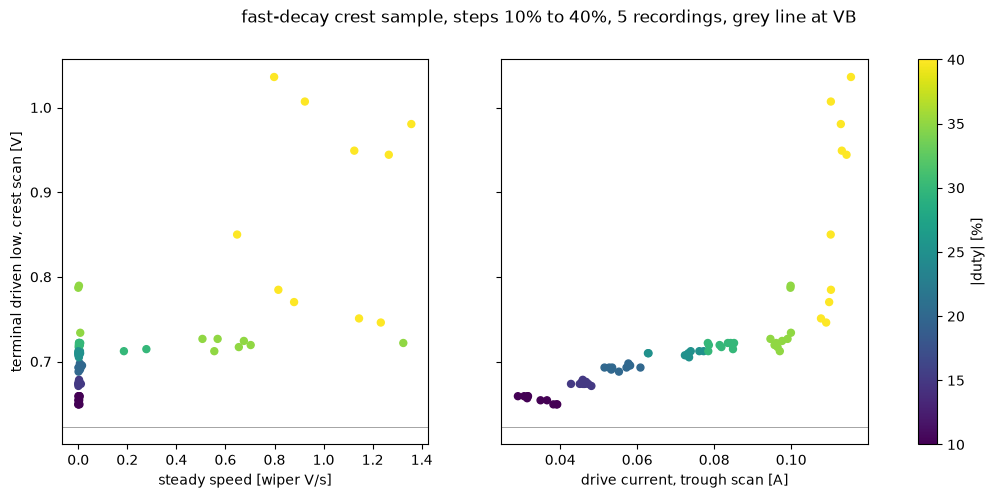

,steps,speed_mean_Vps,speed_max_Vps,reading_mean_V,reading_min_V,reading_max_V,high_terminal_mean_V,difference_mean_V,drive_current_A,corr_reading_speed_within_duty
duty_mag,,,,,,,,,,
10,10,0.003,0.005,0.655,0.649,0.659,0.595,-0.060,0.034,NaN
15,10,0.003,0.011,0.674,0.671,0.678,0.545,-0.129,0.046,NaN
20,10,0.006,0.015,0.693,0.688,0.698,0.467,-0.226,0.056,NaN
25,10,0.003,0.008,0.709,0.705,0.712,0.317,-0.393,0.072,NaN
30,10,0.050,0.278,0.719,0.712,0.722,0.137,-0.582,0.082,-0.806
35,10,0.500,1.325,0.736,0.712,0.790,-0.081,-0.818,0.098,-0.699
40,10,1.019,1.358,0.882,0.746,1.036,-0.346,-1.229,0.111,0.048


In [13]:
def fast_steps(df):
    vb = bias_counts(df)
    bias = current_bias(df)
    out = []
    for seg_id, seg in df.groupby("seg"):
        d = seg["duty_pct"].iloc[0]
        if seg_id == 0 or d == 0:
            continue
        high, low = ("vmotor_a", "vmotor_b") if d > 0 else ("vmotor_b", "vmotor_a")
        out.append({
            "duty_pct": d,
            "duty_mag": round(abs(d)),
            "speed_Vps": abs(step_speed(seg)),
            "reading_V": terminal_V(seg[low].median(), vb),
            "high_terminal_V": terminal_V(seg[high].median(), vb),
            "difference_V": np.sign(d) * DIV_RATIO * (seg["vmotor_a"] - seg["vmotor_b"]).median() * V_ADC_PER_COUNT,
            "drive_current_A": (seg["current_trough"].mean() - bias) * A_PER_COUNT,
        })
    return pd.DataFrame(out)

steps_b = pd.concat([fast_steps(df).assign(recording=n) for n, (df, _) in fast.items()],
                    ignore_index=True)
sel = steps_b[(steps_b["duty_mag"] >= 10) & (steps_b["duty_mag"] <= 40)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, x, xlabel in [(axes[0], "speed_Vps", "steady speed [wiper V/s]"),
                      (axes[1], "drive_current_A", "drive current, trough scan [A]")]:
    sc = ax.scatter(sel[x], sel["reading_V"], c=sel["duty_mag"], cmap="viridis", s=25)
    ax.axhline(VB_NOMINAL_V, color="grey", lw=0.5)
    ax.set_xlabel(xlabel)
axes[0].set_ylabel("terminal driven low, crest scan [V]")
fig.colorbar(sc, ax=axes, label="|duty| [%]")
fig.suptitle("fast-decay crest sample, steps 10% to 40%, 5 recordings, grey line at VB")
plt.show()

by_duty = sel.groupby("duty_mag").agg(
    steps=("speed_Vps", "size"),
    speed_mean_Vps=("speed_Vps", "mean"),
    speed_max_Vps=("speed_Vps", "max"),
    reading_mean_V=("reading_V", "mean"),
    reading_min_V=("reading_V", "min"),
    reading_max_V=("reading_V", "max"),
    high_terminal_mean_V=("high_terminal_V", "mean"),
    difference_mean_V=("difference_V", "mean"),
    drive_current_A=("drive_current_A", "mean"),
)
by_duty["corr_reading_speed_within_duty"] = sel.groupby("duty_mag").apply(
    lambda g: np.corrcoef(g["speed_Vps"], g["reading_V"])[0, 1] if g["speed_Vps"].std() > 0.01 else np.nan,
    include_groups=False)
by_duty.round(3)


Findings:

- From 10% to 25% the servo does not move (speed under 0.02 wiper V/s in
  every recording) while the reading climbs from 0.66 V to 0.71 V with
  duty, 0.03 to 0.09 V above the 0.62 V level of a floating terminal at
  rest. A back-EMF is zero at zero speed.
- At 30% and 35%, where some recordings moved and some stalled, the
  reading falls as speed rises within the duty (correlation -0.81 and
  -0.70 across the ten steps of each). The stalled recordings read higher.
- The terminal driven high falls with duty, from 0.60 V at 10% to -0.35 V
  at 40%, so the bias-free difference is opposite to the drive direction
  and grows with the drive current, from -0.06 V to -1.23 V.
- Against the drive current the reading is a single rising curve across
  all duties. Against speed it is a ladder of duty levels.

The reading tracks the winding current and has the wrong sign for a
back-EMF in the drive direction. It is not a back-EMF, and no $K_e$ is
taken from it. In this scan geometry the direct back-EMF is available only
from the coast segments, where the winding floats for the whole segment
and no PWM edge precedes the sample.

## 7. Route C: coast-down

### 7.1 Method

Within each coast segment the winding floats for 400 ms while the
mechanism spins down. Both terminals are readable, so the back-EMF is the
bias-free terminal difference

$$e = V_a - V_b = 3\,(v_{\mathrm{tap},a} - v_{\mathrm{tap},b})$$

which is positive during a forward coast and negative during a reverse
one, the same sign convention as the wiper speed. The samples of a coast
segment fall into three phases, and the histogram below separates them by
the corrected terminal sum $V_a + V_b$. It pools every coast sample of all
30 segments, split by position in the segment.

- The first two samples of a segment still read the drive, one terminal at
  the rail and the other near ground, so the sum sits at the rail, 7.4 V.
- The body-diode phase, while the winding current returns to the supply,
  puts one terminal a diode drop above the rail and the other a diode drop
  below ground. With drive currents of 0.1 A it lasts at most one sample,
  and the sum sits at 7.6 V.
- From then on the winding floats and the sum is the back-EMF plus twice
  the level of the negative terminal, under 2.7 V.

The gate is the corrected sum against half the rail. A sample is in the
drive or diode phase when $V_a + V_b$ exceeds half the rail, and only
samples from the third onward below that level are used. In a few segments
one further sample follows the diode phase with the polarity reversed, the
positive terminal at the diode level below ground and the other above it.
That sample fails the sign gate below.


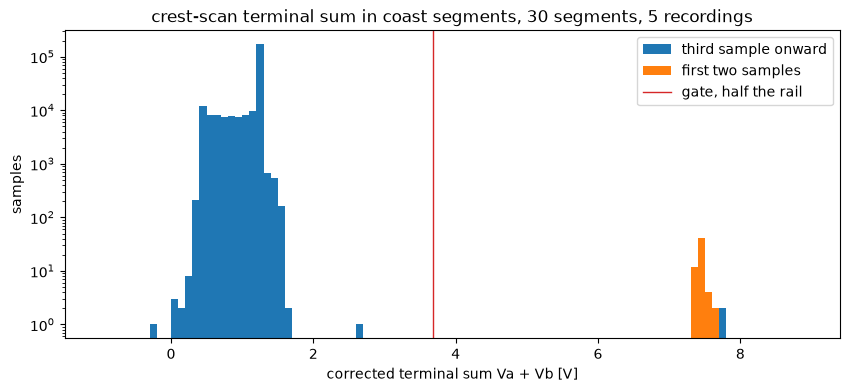

,samples,min_V,max_V,above_gate
first two samples,60,7.368,7.689,60
third sample onward,239940,-0.238,7.706,4


In [14]:
def schedule_kinds(meta):
    kinds = []
    for _ in meta["dirs"]:
        level = None
        for entry in meta["schedule"]:
            if ":" in entry:
                kinds.append((entry.split(":")[0], level))
            else:
                level = float(entry)
                kinds.append(("drive", level))
    return kinds

def coast_segments(df, meta):
    kinds = schedule_kinds(meta)
    for seg_id, seg in df.groupby("seg"):
        if seg_id > 0 and kinds[seg_id - 1][0] == "coast":
            yield seg_id, kinds[seg_id - 1][1], seg

RAIL_V = pd.concat([s["rail_V"] for s in steps_a.values()]).mean()
SUM_GATE_V = RAIL_V / 2                  # corrected terminal sum above this is drive or diode phase

def terminals(seg, vb):
    return terminal_V(seg["vmotor_a"].to_numpy(), vb), terminal_V(seg["vmotor_b"].to_numpy(), vb)

first_two, later = [], []
for df, meta in spin.values():
    vb = bias_counts(df)
    for _, _, seg in coast_segments(df, meta):
        va, vb_ = terminals(seg, vb)
        total = va + vb_
        first_two.append(total[:2])
        later.append(total[2:])
first_two, later = np.concatenate(first_two), np.concatenate(later)

fig, ax = plt.subplots(figsize=(10, 4))
bins = np.arange(-1, 9, 0.1)
ax.hist(later, bins=bins, log=True, color="tab:blue", label="third sample onward")
ax.hist(first_two, bins=bins, log=True, color="tab:orange", label="first two samples")
ax.axvline(SUM_GATE_V, color="tab:red", lw=1, label="gate, half the rail")
ax.set_xlabel("corrected terminal sum Va + Vb [V]")
ax.set_ylabel("samples")
ax.set_title("crest-scan terminal sum in coast segments, 30 segments, 5 recordings")
ax.legend()
plt.show()

pd.DataFrame({
    "samples": [len(first_two), len(later)],
    "min_V": [first_two.min(), later.min()],
    "max_V": [first_two.max(), later.max()],
    "above_gate": [(first_two > SUM_GATE_V).sum(), (later > SUM_GATE_V).sum()],
}, index=["first two samples", "third sample onward"]).round(3)


The two populations do not touch. The first two samples of every segment
read the drive or the diode phase, 7.37 to 7.69 V, and four later samples,
the third sample of four segments, sit at 7.7 V in the diode phase. The
gate at 3.7 V sits in the empty band between 2.6 V and 7.4 V.

Per sample from the third onward:

- **Back-EMF** $e$ as defined above, in volts at the terminals.
- **Speed** $\omega$ from a centred least-squares line over 41 samples
  (2 ms) of the wiper trace, evaluated at every sample.
- The used span runs from the first sample past the gate with $e$ of at
  least 0.02 V in the coast direction, which is the sign gate, to the
  first sample at which $|e|$ drops below 0.02 V, so the decay is covered
  and the span stops when the mechanism has come to rest. The regression
  additionally needs the centred window to fit inside the segment, which
  drops the first millisecond.

The wiper carries the noise. One ADC count over a 2 ms window is a speed
error of 0.4 V/s while the terminal difference is clean to 2.4 mV, so the
fit minimizes speed residuals, $\omega = e / K_e + \omega_0$, and reports
$K_e$ as the inverse slope. A regression of $e$ on the noisy speed would
read low by the noise-to-signal ratio of the speed. As an independent
check that needs no derivative, the integral of $e$ over the used span
divided by the wiper travel over the same span gives $K_e$ again, since
$\int e\,dt = K_e \int \omega\,dt = K_e\,\Delta p$.


In [15]:
DERIV_WINDOW = 41          # samples, 2 ms centred fit
E_MIN_V = 0.02             # terminal volts, about 8 counts of tap difference
FIRST_SAMPLE = 2           # third sample of the segment onward

def coast_trace(seg, vb):
    d = int(seg["dir"].iloc[0])
    pos = seg["pos"].to_numpy() * V_ADC_PER_COUNT
    w = savgol_filter(pos, DERIV_WINDOW, 1, deriv=1, delta=1.0 / TICK_HZ)
    va, vb_ = terminals(seg, vb)
    e = va - vb_
    idx = np.arange(len(seg))
    ok = (idx >= FIRST_SAMPLE) & (va + vb_ < SUM_GATE_V) & (d * e >= E_MIN_V)
    start = np.flatnonzero(ok)[0]
    stop = np.flatnonzero(~ok & (idx > start))[0]      # mechanism at rest
    used = (idx >= start) & (idx < stop)
    # the centred derivative exists only where the window fits inside the segment
    fit = used & (idx >= DERIV_WINDOW // 2) & (idx < len(seg) - DERIV_WINDOW // 2)
    return idx / TICK_HZ, pos, w, e, used, fit, va, vb_

def coast_fits(df, meta):
    vb = bias_counts(df)
    out = []
    for seg_id, level, seg in coast_segments(df, meta):
        d = int(seg["dir"].iloc[0])
        t, pos, w, e, used, fit, va, vb_ = coast_trace(seg, vb)
        slope, icpt = np.polyfit(e[fit], w[fit], 1)
        span = np.flatnonzero(used)
        integral = np.trapezoid(e[used], t[used])
        travel = pos[span[-1]] - pos[span[0]]
        positive, negative = (va, vb_) if d > 0 else (vb_, va)
        out.append({
            "seg": seg_id,
            "direction": d,
            "drive_pct": level,
            "samples_used": int(used.sum()),
            "samples_fit": int(fit.sum()),
            "decay_ms": (span[-1] - span[0]) / TICK_HZ * 1e3,
            "e_start_V": e[span[0]],
            "negative_terminal_V": np.median(negative[span[0]:span[0] + 400]),
            "Ke_fit": 1.0 / slope,
            "w_intercept_Vps": icpt,
            "Ke_integral": integral / travel,
            "integral_Vs": integral,
            "travel_V": travel,
        })
    return pd.DataFrame(out)

coasts = pd.concat([coast_fits(df, meta).assign(recording=n) for n, (df, meta) in spin.items()],
                   ignore_index=True)
coasts[coasts["recording"] == "bridge/capture-1"].set_index("seg").drop(
    columns=["recording", "integral_Vs", "travel_V"]).round(4)


,direction,drive_pct,samples_used,samples_fit,decay_ms,e_start_V,negative_terminal_V,Ke_fit,w_intercept_Vps,Ke_integral
seg,,,,,,,,,,
2,1,20.0,1264,1247,63.15,0.9982,-0.1386,0.3115,0.2327,0.2787
6,1,30.0,2630,2612,131.45,1.4357,-0.4431,0.2733,-0.2617,0.3013
10,1,40.0,3574,3556,178.65,1.9191,-0.4673,0.3174,0.1702,0.3037
14,-1,20.0,1757,1739,87.80,-0.7009,-0.1482,0.2179,0.4067,0.2667
18,-1,30.0,2818,2801,140.85,-1.3535,-0.4528,0.2904,0.0530,0.2934
22,-1,40.0,3557,3539,177.80,-1.9578,-0.4818,0.3001,-0.0876,0.2951


### 7.2 One decay

The forward coast after the 40% step of the first recording. The left
panel shows both terminals in corrected volts and their difference, the
middle panel the back-EMF and the wiper speed on one time axis, and the
right panel the fit.


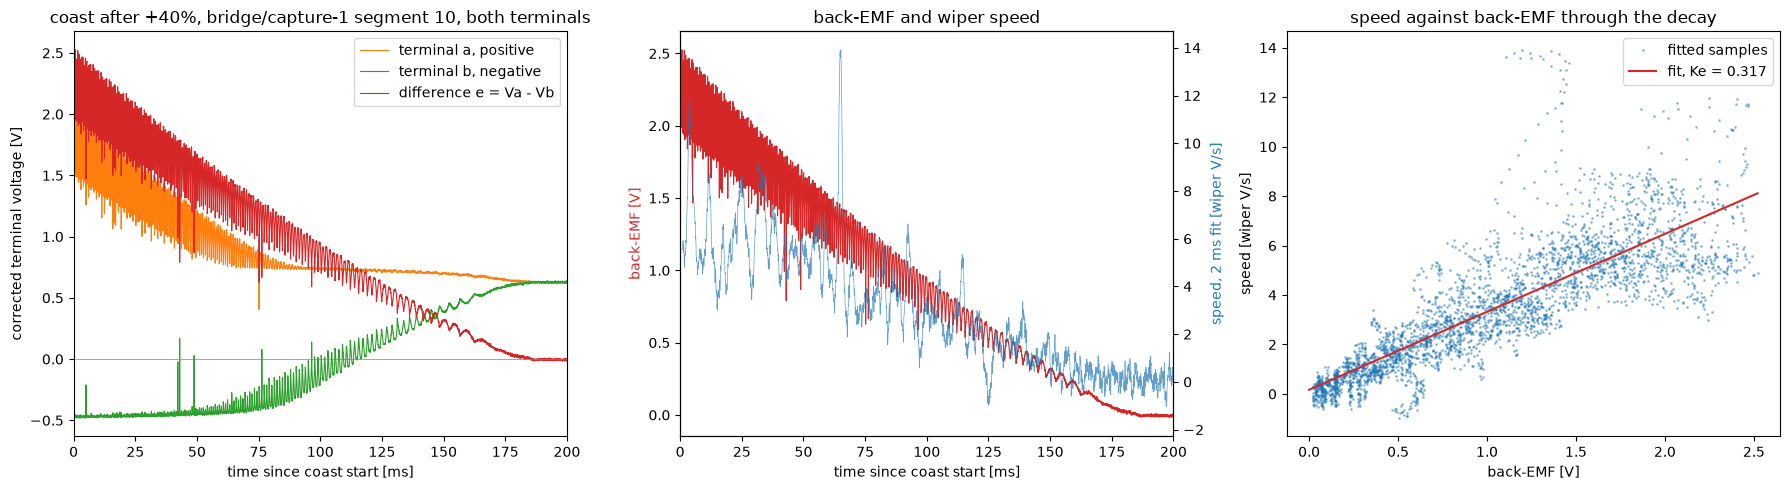

,samples_used,samples_fit,decay_ms,e_start_V,negative_terminal_V,Ke_fit,w_intercept_Vps,Ke_integral
2,3574,3556,178.65,1.9191,-0.4673,0.3174,0.1702,0.3037


In [16]:
df_s, meta_s = spin["bridge/capture-1"]
seg_id = int(coasts[(coasts["recording"] == "bridge/capture-1")
                    & (coasts["direction"] == 1) & (coasts["drive_pct"] == 40)]["seg"].iloc[0])
seg = df_s[df_s["seg"] == seg_id]
t, pos, w, e, used, fit, va, vb_ = coast_trace(seg, bias_counts(df_s))
row = coasts[(coasts["recording"] == "bridge/capture-1") & (coasts["seg"] == seg_id)].iloc[0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ax = axes[0]
ax.plot(t[FIRST_SAMPLE:] * 1e3, va[FIRST_SAMPLE:], color="tab:orange", lw=0.8, label="terminal a, positive")
ax.plot(t[FIRST_SAMPLE:] * 1e3, vb_[FIRST_SAMPLE:], color="tab:green", lw=0.8, label="terminal b, negative")
ax.plot(t[FIRST_SAMPLE:] * 1e3, e[FIRST_SAMPLE:], color="tab:red", lw=0.8, label="difference e = Va - Vb")
ax.axhline(0, color="grey", lw=0.5)
ax.set_xlim(0, 200)
ax.set_xlabel("time since coast start [ms]")
ax.set_ylabel("corrected terminal voltage [V]")
ax.set_title(f"coast after +40%, bridge/capture-1 segment {seg_id}, both terminals")
ax.legend()
ax = axes[1]
ax.plot(t[FIRST_SAMPLE:] * 1e3, e[FIRST_SAMPLE:], color="tab:red", lw=0.8)
ax.set_xlabel("time since coast start [ms]")
ax.set_ylabel("back-EMF [V]", color="tab:red")
ax2 = ax.twinx()
ax2.plot(t * 1e3, w, color="tab:blue", lw=0.5, alpha=0.7)
ax2.set_ylabel("speed, 2 ms fit [wiper V/s]", color="tab:blue")
ax.set_xlim(0, 200)
ax.set_title("back-EMF and wiper speed")
ax = axes[2]
ax.plot(e[fit], w[fit], ".", ms=2, alpha=0.4, label="fitted samples")
ee = np.linspace(0, e[fit].max(), 10)
ax.plot(ee, ee / row["Ke_fit"] + row["w_intercept_Vps"], color="tab:red",
        label=f"fit, Ke = {row['Ke_fit']:.3f}")
ax.set_xlabel("back-EMF [V]")
ax.set_ylabel("speed [wiper V/s]")
ax.set_title("speed against back-EMF through the decay")
ax.legend()
fig.tight_layout()
plt.show()

pd.DataFrame([row[["samples_used", "samples_fit", "decay_ms", "e_start_V", "negative_terminal_V",
                   "Ke_fit", "w_intercept_Vps", "Ke_integral"]]]).round(4)


The back-EMF starts at 1.9 V and decays to zero within about 180 ms. The
negative terminal sits at -0.47 V while the back-EMF is above about 1.2 V,
the level at which the body diode of the low-side switch conducts, and
lifts toward the 0.62 V rest level as the back-EMF falls, while the
positive terminal carries the rest of the swing. The single-terminal
reading is therefore a fraction of $e$ that changes through the decay, and
the difference removes it. Both traces carry a ripple of about 2 kHz at the
start of the coast, about 0.5 V peak on the back-EMF. *Hypothesis (not tested
here): this is the commutation ripple of the motor.* The scatter is a line
with the noise spread along the speed axis.

### 7.3 All coast segments

Thirty coast segments, six per recording. The first table groups them by
direction and by the drive level that preceded the coast, which sets the
starting speed. The second pools each recording's six segments, with the
regression over all their used samples and the ratio of the summed
integrals to the summed travel, both taken in the coast direction.


In [17]:
grouped = coasts.groupby(["direction", "drive_pct"]).agg(
    segments=("seg", "size"),
    e_start_V=("e_start_V", lambda x: x.abs().mean()),
    negative_terminal_V=("negative_terminal_V", "mean"),
    Ke_fit_mean=("Ke_fit", "mean"),
    Ke_fit_std=("Ke_fit", "std"),
    Ke_integral_mean=("Ke_integral", "mean"),
    Ke_integral_std=("Ke_integral", "std"),
)
overall = pd.DataFrame({
    "segments": [len(coasts)],
    "e_start_V": [coasts["e_start_V"].abs().mean()],
    "negative_terminal_V": [coasts["negative_terminal_V"].mean()],
    "Ke_fit_mean": [coasts["Ke_fit"].mean()],
    "Ke_fit_std": [coasts["Ke_fit"].std()],
    "Ke_integral_mean": [coasts["Ke_integral"].mean()],
    "Ke_integral_std": [coasts["Ke_integral"].std()],
}, index=pd.MultiIndex.from_tuples([("all", "all")], names=["direction", "drive_pct"]))
pd.concat([grouped, overall]).round(4)


segments  e_start_V  negative_terminal_V  Ke_fit_mean  \
direction drive_pct                                                          
-1        20.0              5     0.7507              -0.1550       0.2335   
          30.0              5     1.3477              -0.4557       0.2901   
          40.0              5     2.0844              -0.4837       0.3151   
1         20.0              5     0.8450              -0.1424       0.3366   
          30.0              5     1.5768              -0.4455       0.2828   
          40.0              5     1.8732              -0.4687       0.3112   
all       all              30     1.4130              -0.3585       0.2949   

                     Ke_fit_std  Ke_integral_mean  Ke_integral_std  
direction drive_pct                                                 
-1        20.0           0.0253            0.2751           0.0143  
          30.0           0.0061            0.2944           0.0044  
          40.0           0.0105            0.2958           0.0009  
1         20.0           0.0330            0.2798           0.0193  
          30.0           0.0258            0.3033           0.0033  
          40.0           0.0040            0.2970           0.0051  
all       all            0.0380            0.2909           0.0138

In [18]:
rows = []
for name, (df, meta) in spin.items():
    vb = bias_counts(df)
    es, ws = [], []
    for _, _, seg in coast_segments(df, meta):
        _, _, w, e, used, fit, _, _ = coast_trace(seg, vb)
        es.append(e[fit])
        ws.append(w[fit])
    es, ws = np.concatenate(es), np.concatenate(ws)
    slope, icpt = np.polyfit(es, ws, 1)
    c = coasts[coasts["recording"] == name]
    rows.append({"recording": name, "samples": len(es),
                 "Ke_regression": 1.0 / slope, "w_intercept_Vps": icpt,
                 "Ke_integral": (c["direction"] * c["integral_Vs"]).sum() / (c["direction"] * c["travel_V"]).sum()})
pooled_c = pd.DataFrame(rows).set_index("recording")
summary_c = pooled_c[["Ke_regression", "Ke_integral"]].agg(["mean", "std", "min", "max"]).T
summary_c["spread_pct"] = summary_c["std"] / summary_c["mean"] * 100
pd.concat([pooled_c.round(4), summary_c.round(4)], axis=0).fillna("")


,samples,Ke_regression,w_intercept_Vps,Ke_integral,mean,std,min,max,spread_pct
bridge/capture-1,15494.0,0.2961,-0.043,0.295,,,,,
bridge/capture-2,14970.0,0.2954,0.017,0.2919,,,,,
bridge/capture-3,15857.0,0.3007,-0.0679,0.2968,,,,,
bridge/capture-4,15541.0,0.2969,0.0066,0.2944,,,,,
bridge/capture-5,16112.0,0.2993,0.0213,0.2938,,,,,
Ke_regression,,,,,0.2977,0.0022,0.2954,0.3007,0.7551
Ke_integral,,,,,0.2944,0.0018,0.2919,0.2968,0.6072


Findings:

- The per-segment integral is flat against the starting speed within a few
  percent, 0.28 after a 20% step, 0.30 after 30% and 0.30 after 40%, with
  a spread inside each group of 0.3 to 7%. Forward and reverse agree
  within each group to 3% or better.
- The per-segment regression scatters more (13% overall). The 2 ms
  derivative carries the pot quantization and the ripple, and the short
  20% coasts, 63 to 90 ms of decay, give it the least to work with. The
  integral needs no derivative and is the figure to trust per segment.
- Pooled per recording, the integral ratio gives 0.294 and the regression
  0.298, each repeating to under 1% across the five recordings.
- The negative terminal sits at -0.45 to -0.48 V through the 30% and 40%
  coasts and at -0.14 to -0.16 V through the 20% coasts, whose back-EMF
  starts below the diode level.

## 8. Agreement

The table collects every estimate with its spread. Route A is listed as
the free joint fit, whose spread is the collinearity of section 5.3, and
as the anchored result of section 5.5, whose spread combines the recording
spread with the shift induced by the anchor's bracket. Route C is listed
per segment (30 segments) and pooled per recording (5 recordings). The
last column is each estimate's difference from the anchored route A.


In [19]:
a_joint = fits_a["Ke_V_per_Vps"]
rows = [
    {"route": "A joint fit, free R", "Ke": a_joint.mean(), "spread": a_joint.std(), "n": len(a_joint), "n_unit": "recordings"},
    {"route": "A with R anchored", "Ke": KE_A, "spread": KE_A_SPREAD, "n": len(ke_anchor), "n_unit": "recordings"},
    {"route": "C regression, per segment", "Ke": coasts["Ke_fit"].mean(), "spread": coasts["Ke_fit"].std(), "n": len(coasts), "n_unit": "coast segments"},
    {"route": "C integral, per segment", "Ke": coasts["Ke_integral"].mean(), "spread": coasts["Ke_integral"].std(), "n": len(coasts), "n_unit": "coast segments"},
    {"route": "C regression, pooled per recording", "Ke": pooled_c["Ke_regression"].mean(), "spread": pooled_c["Ke_regression"].std(), "n": len(pooled_c), "n_unit": "recordings"},
    {"route": "C integral, pooled per recording", "Ke": pooled_c["Ke_integral"].mean(), "spread": pooled_c["Ke_integral"].std(), "n": len(pooled_c), "n_unit": "recordings"},
]
agree = pd.DataFrame(rows).set_index("route")
agree["spread_pct"] = agree["spread"] / agree["Ke"] * 100
agree["vs_A_anchored_pct"] = (agree["Ke"] / KE_A - 1) * 100
agree.round(4)


,Ke,spread,n,n_unit,spread_pct,vs_A_anchored_pct
route,,,,,,
"A joint fit, free R",0.3304,0.0261,15,recordings,7.8857,18.6150
A with R anchored,0.2786,0.0067,15,recordings,2.4012,0.0000
"C regression, per segment",0.2949,0.0380,30,coast segments,12.9035,5.8550
"C integral, per segment",0.2909,0.0138,30,coast segments,4.7502,4.4271
"C regression, pooled per recording",0.2977,0.0022,5,recordings,0.7551,6.8580
"C integral, pooled per recording",0.2944,0.0018,5,recordings,0.6072,5.6797


In [20]:
def verdict(name):
    gap = agree.loc[name, "vs_A_anchored_pct"]
    combined = agree.loc["A with R anchored", "spread_pct"] + agree.loc[name, "spread_pct"]
    return {"route C estimate": name, "gap_pct": gap, "combined_spreads_pct": combined,
            "beyond_spreads_pct": max(abs(gap) - combined, 0), "within_spreads": abs(gap) <= combined}

KE_C = pooled_c["Ke_integral"].mean()
KE_ADOPTED = (KE_A + KE_C) / 2
KE_BRACKET_LO = ke_anchor["Ke_at_R_upper"].mean()
KE_BRACKET_HI = pooled_c["Ke_regression"].mean() + pooled_c["Ke_regression"].std()
pd.DataFrame([verdict("C integral, pooled per recording"),
              verdict("C regression, pooled per recording"),
              verdict("C integral, per segment")]).set_index("route C estimate").round(3)


,gap_pct,combined_spreads_pct,beyond_spreads_pct,within_spreads
route C estimate,,,,
"C integral, pooled per recording",5.680,3.008,2.671,False
"C regression, pooled per recording",6.858,3.156,3.702,False
"C integral, per segment",4.427,7.151,0.000,True


In [21]:
pd.DataFrame([{
    "Ke_adopted": KE_ADOPTED,
    "bracket_low": KE_BRACKET_LO,
    "bracket_high": KE_BRACKET_HI,
    "half_width": (KE_BRACKET_HI - KE_BRACKET_LO) / 2,
    "half_width_pct": (KE_BRACKET_HI - KE_BRACKET_LO) / 2 / KE_ADOPTED * 100,
}]).round(4)


,Ke_adopted,bracket_low,bracket_high,half_width,half_width_pct
0,0.2865,0.2721,0.2999,0.0139,4.8613


**Verdict.** The two routes sit 5 to 7% apart, route C above route A,
against a factor of 1.5 to 1.9 on the earlier single-terminal reading. The acceptance
rule for a measured $K_e$ is two independent routes agreeing within their
stated spreads. Against the pooled route C figures, whose spreads are under
1%, the gap exceeds the combined spreads by 2 to 4 points and the rule is
not met. Against the per-segment integral, whose 4.7% spread is the
segment-to-segment scatter, the rule is met, and that is a weaker yardstick.

What remains is a few percent, and two known systematics are of that
size.

- **The pot speed axis.** Both routes divide a voltage by the pot's speed,
  so a scale error of the wiper cancels in the comparison, but the two
  routes read the pot in different ways. Route A takes a 48 ms slope of a
  step at one region of travel, route C integrates the travel of a decay
  and regresses a 2 ms derivative that carries the 2 kHz ripple. A
  position-dependent wiper gain, and the ripple, act on the two routes
  differently.
- **The R anchor.** The residual motion at the step edge leaves $R$
  between 4.10 and 4.56 Ohm, and route A moves from 0.285 to 0.272 across
  that bracket. The upper end of the bracket, which the later windows
  favour, widens the gap.

The bracket that covers both routes runs from 0.272, route A at the upper
$R$ bound, to 0.300, the pooled regression plus its spread. Later
notebooks take the midpoint of the two routes, $K_e$ = 0.287 V per wiper
V/s, with the half-width of that bracket, 0.014 or 5%, as its uncertainty.

## 9. Limitations and open issues

- **Nominal VDD.** $R$ and every voltage scale with the true VDD of this
  unit, which was not measured. $K_e$ is a ratio of two VDD-referenced
  voltages and is unaffected.
- **One servo, one supply.** All numbers describe this one unit on a
  2-cell battery, in one session without recharging, at a rail of 7.36 V.
- **Route A collinearity.** Current and speed are 99.8% correlated across
  the grid, so the joint fit cannot split $R$ from $K_e$ and the anchor of
  section 5.4 carries the split.
- **Residual motion on the R anchor.** Every full-duty step enters with
  the mechanism moving backward at about 2.6 wiper V/s from the seek, so
  the anchor window reads a backward EMF of about 0.7 V on top of $R\,i$.
  The bounds of section 5.4 bracket $R$ to 5%, and that bracket is the
  largest term in the route A uncertainty. A seek that ends in a rest
  before the step would remove it.
- **Applied-voltage estimate.** Route A takes the driven terminal as the
  90th percentile of its crest samples. At 100% duty that sits about 2.5%
  above the mean of the terminal difference, which the anchor window uses.
  Taking the mean instead would lower route A by up to that amount.
- **Route A speeds.** The slowest steps have not reached steady speed at
  the end of the 80 ms window (notebook 00, section 7), so their speeds
  read low and the residuals are structured.
- **Pot speed axis.** The wiper's volts per radian along its travel, and
  the 2 kHz ripple on the decay, are the systematics that the residual gap
  between the routes points at. Neither is measured here.
- **Rejected candidate.** The fast-decay crest sample reads a
  current-dependent transient with the wrong sign at 10% to 40% duty. In
  this scan geometry it is not a back-EMF channel.
- **Gear ratio unknown.** $K_e$ is referenced to the pot wiper. The motor
  shaft constant is this value times the wiper volts per motor radian,
  which requires the gear ratio and the pot's volts per radian.

## 10. What later notebooks use

- $K_e$ = 0.287 V per wiper V/s, the midpoint of the two routes, with a
  bracket of 0.272 to 0.300 that covers both routes and their spreads.
- $R$ = 4.33 Ohm from the full-duty anchor, with the 4.10 to 4.56 Ohm
  bracket of the residual-motion caveat, and the route A combination
  $R + 35\,K_e \approx 13.9$ Ohm, which is what the steady-state drive
  data pins on its own.
- The terminal conversion $V_t = 3\,v_{\mathrm{tap}} - 2\,V_B$ with $V_B$
  from the baseline median of the recording, and the fact that terminal
  differences need no bias.
- The current-offset subtraction and the per-step supply estimate of
  notebook 00, reused here unchanged.
- The coast-segment convention of section 7 (back-EMF as the terminal
  difference, third sample onward, sum gate at half the rail, sign gate
  at 0.02 V, 2 ms centred derivative, speed regressed on back-EMF, integral
  cross-check).
- The negative terminal of a floating winding sits at the diode level of
  about -0.46 V whenever the back-EMF exceeds about 1.2 V, so a
  single-terminal reading is a variable fraction of the back-EMF and
  nothing downstream should use one.
- The fast-decay crest sample is a current channel in the OFF portion, and
  nothing downstream should read it as back-EMF.
